# 二、Transformer

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# 自动选择设备（有GPU用GPU，无GPU用CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前运行设备: {device}")

当前运行设备: cpu


## 1.自注意力机制
下述模型构造随机序列模拟文本特征，通过线性投影生成查询 Q、键 K、值 V，计算序列内部各个位置之间的注意力权重。最后将注意力权重矩阵绘制热力图，直观展示序列中每个 token 对其他 token 的关注程度，理解自注意力如何捕获序列全局依赖关系。

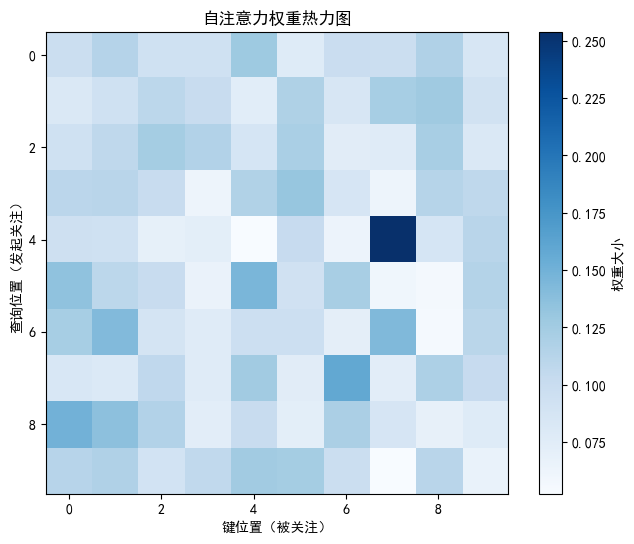

In [2]:
# 1.定义自注意力模型
def self_attention(Q, K, V, mask=None):
   
    d_k = Q.size(-1)
    # 1. 计算注意力分数
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    
    # 掩码（解码器中使用，屏蔽未来位置）
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    
    # 2. 归一化得到权重
    attn_weights = torch.softmax(scores, dim=-1)
    # 3. 加权求和得到输出
    output = torch.matmul(attn_weights, V)
    return output, attn_weights

# 2.测试 
seq_len = 10
d_model = 32
x = torch.randn(1, seq_len, d_model)  # 1个样本，10个词，32维特征

# 3.可视化
# 线性变换生成 Q、K、V
Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)
Q, K, V = Wq(x), Wk(x), Wv(x)
out, attn = self_attention(Q, K, V)

# 可视化注意力权重
plt.figure(figsize=(8, 6))
plt.imshow(attn[0].detach().numpy(), cmap='Blues')
plt.xlabel('键位置（被关注）')
plt.ylabel('查询位置（发起关注）')
plt.title('自注意力权重热力图')
plt.colorbar(label='权重大小')
plt.show()

分析：
* 纵轴为发起关注的查询位置，横轴为被关注的键位置，颜色越深代表注意力权重越高。
* 图中查询位置 4、键位置 7颜色最深，说明第 4 个 token 对第 7 个 token 关注度最高。
* 强关联出现在相距较远的两个位置，体现自注意力能够捕捉序列远距离依赖。

## 2.多头注意力
下述模型将原始特征投影、切分为 4 个独立注意力头，每个头并行执行缩放点积自注意力，分别学习不同的关联模式，最后拼接所有头的特征并融合输出。通过可视化各个注意力头的权重热力图，可以观察不同注意力头具备差异化的关注模式，体现多头注意力能够并行捕获多种序列依赖。

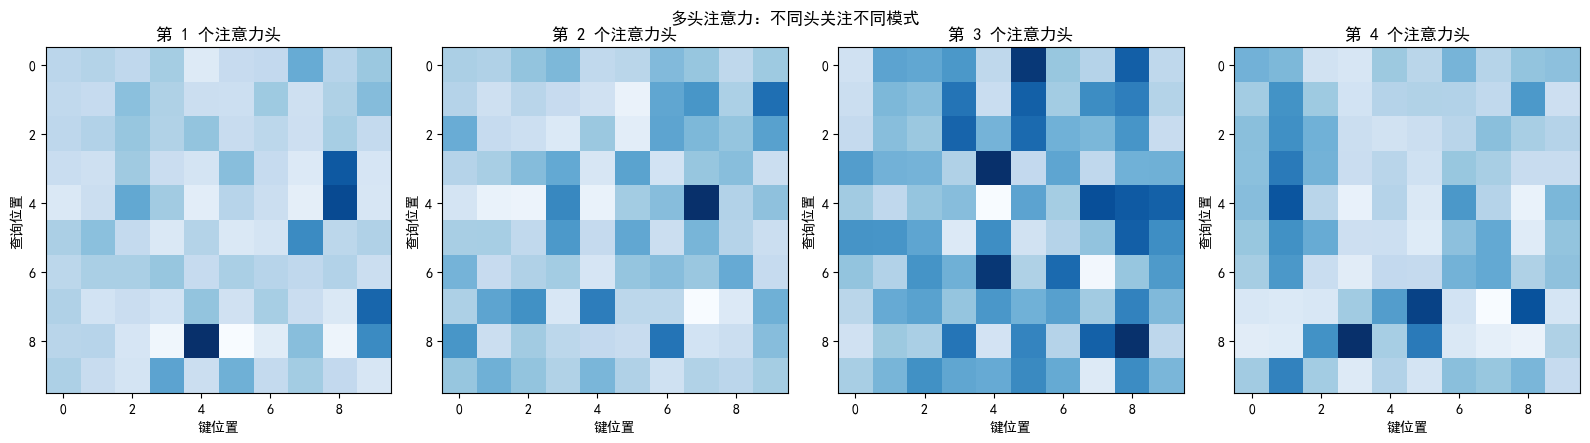

In [3]:
# 1.定义多头注意力模型
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "维度必须能被头数整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)  # 输出投影
    
    def forward(self, x, mask=None):
        batch_size = x.size(0)
        # 1. 生成 QKV 并拆分成多个头
        Q = self.Wq(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.Wk(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.Wv(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. 每个头独立计算自注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, V)
        
        # 3. 拼接多头结果并投影
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        out = self.Wo(out)
        return out, attn_weights

# 2.测试与可视化 
mha = MultiHeadAttention(d_model=32, num_heads=4)
out, attn = mha(x)

# 可视化 4 个不同的注意力头
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    im = axes[i].imshow(attn[0, i].detach().numpy(), cmap='Blues')
    axes[i].set_title(f'第 {i+1} 个注意力头')
    axes[i].set_xlabel('键位置')
    axes[i].set_ylabel('查询位置')
plt.tight_layout()
plt.suptitle('多头注意力：不同头关注不同模式', y=1.05)
plt.show()

分析：
* 图中 4 张子图对应 4 个独立注意力头，颜色越深代表注意力权重越高。
* 四个注意力头的图分布互不相同，每个头重点关注的位置组合有明显区别，验证多头注意力可以在不同特征子空间学习独立的关联模式。
* 相比单头自注意力，多头结构拥有更多建模角度，能够同时捕获多种类型的序列依赖。

## 3.ViT（视觉 Transformer）
ViT 将 Transformer 迁移到计算机视觉：把图片切分成多个小块，每个小块类比一个 "词"，加上位置编码后送入 Transformer 编码器，最终完成图像分类。

Epoch 1/5 | 损失: 0.4634 | 准确率: 84.79%
Epoch 2/5 | 损失: 0.1602 | 准确率: 94.99%
Epoch 3/5 | 损失: 0.1201 | 准确率: 96.20%
Epoch 4/5 | 损失: 0.1010 | 准确率: 96.82%
Epoch 5/5 | 损失: 0.0874 | 准确率: 97.17%


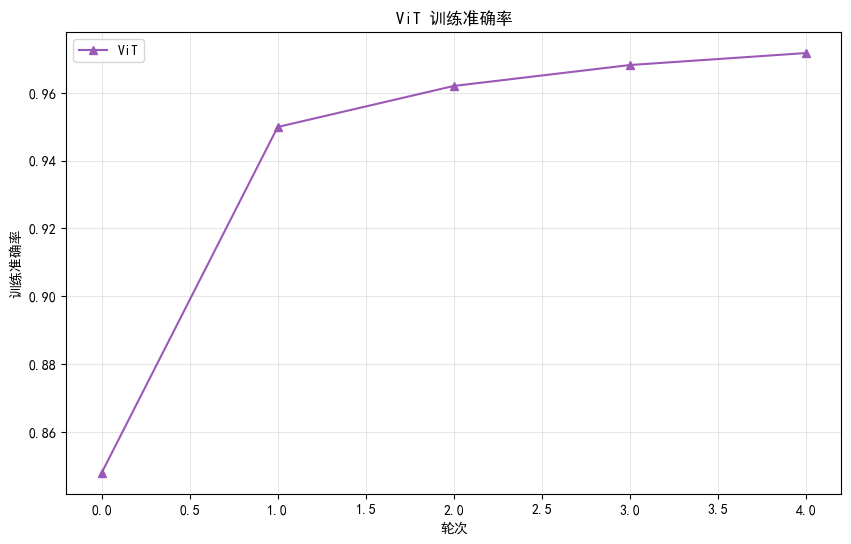

In [7]:
# 1.MNIST数据集加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2.定义训练函数 
def train_classifier(model, train_loader, criterion, optimizer, epochs=5):
    train_loss = []
    train_acc = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        train_loss.append(avg_loss)
        train_acc.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | 损失: {avg_loss:.4f} | 准确率: {acc:.2%}")
    return train_loss, train_acc

# 3.Transformer编码器层
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.activation = nn.GELU()

    def forward(self, x):
        # 多头自注意力
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        # FFN前馈网络
        ffn_out = self.linear2(self.activation(self.linear1(x)))
        x = self.norm2(x + ffn_out)
        return x

# 4.Patch嵌入层 
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, d_model=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

# 5. ViT模型 
class SimpleViT(nn.Module):
    def __init__(self, img_size=28, patch_size=4, d_model=64, num_heads=4, num_layers=2, num_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 1, d_model)
        num_patches = self.patch_embed.num_patches
        self.position_embedding = nn.Embedding(num_patches, d_model)
        
        self.encoders = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_model*2)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        x = self.patch_embed(x)
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = x + self.position_embedding(pos)
        
        for layer in self.encoders:
            x = layer(x)
        
        x = x.mean(dim=1)
        return self.classifier(x)

# 6. 训练ViT 
vit = SimpleViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit.parameters(), lr=0.001)
vit_loss, vit_acc = train_classifier(vit, train_loader, criterion, optimizer, epochs=5)


# 7.可视化结果
plt.figure(figsize=(10, 6))
plt.plot(vit_acc, '^-', label='ViT', color='#9b59b6')
plt.xlabel('轮次')
plt.ylabel('训练准确率')
plt.title('ViT 训练准确率')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

分析：
* 模型前期快速学习图像块之间的关联特征，后期进入微调阶段，提升幅度变小。
* 轻量化 ViT 能够完成 MNIST 手写数字分类任务，依靠自注意力有效捕捉图像区域依赖。